# Chapter 4: Compactness

**Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Chapter 4, printed pp. 75-114; PDF pp. 90-129. Sections 4.1-4.7 are used for coverage planning only.

**Chapter question.** What can happen to a sequence of J-holomorphic curves with bounded energy, and how does the compactness theorem keep the lost energy from disappearing? This chapter is the analytic bridge between local curve estimates and stable maps. The notebook turns the proof structure into visual checks: energy concentrates at finitely many points, rescaling extracts bubbles with quantized energy, mean-value and isoperimetric inequalities control local behavior, removal of singularities fills punctures, and the limiting components connect into a bubble tree.

The goal is not to reproduce the hard estimates. It is to make the compactness mechanism inspectable. Every visual carries a specific invariant: total energy is conserved, each bubble clears a minimum threshold, the bubble graph is connected, and rescaling separates the base scale from bubble scale.


## Source Coverage

Section 4.1 introduces energy and removal of singularities as the basic compactness currency. Section 4.2 explains bubbling: energy density can concentrate and create nonconstant sphere components. Section 4.3 proves a mean-value inequality that turns small energy into pointwise control. Section 4.4 supplies an isoperimetric inequality for boundary loops. Section 4.5 uses those estimates to prove removal of singularities. Section 4.6 states convergence modulo bubbling, where a sequence converges away from finitely many concentration points and rescalings produce bubbles. Section 4.7 proves that the bubbles connect, giving the tree structure that later becomes stable-map compactification.

The source-coverage artifact records this section map. The notebook pairs each cluster with a generated object: an energy-density heatmap, estimate ledger, rescaling chart, bubble-tree proof graph, and a threshold lab.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd


def find_book_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "J-Holomorphic-Curves-and-Symplectic-Topology" / "AGENTS.md").exists():
            return candidate / "J-Holomorphic-Curves-and-Symplectic-Topology"
        if (candidate / "AGENTS.md").exists() and candidate.name == "J-Holomorphic-Curves-and-Symplectic-Topology":
            return candidate
    raise RuntimeError("Could not locate the JHCST book root")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "chapter-04"
ART_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ART_ROOT / "figures"
CHECK_DIR = ART_ROOT / "checks"
TABLE_DIR = ART_ROOT / "tables"
for directory in (FIG_DIR, CHECK_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


In [2]:
source_coverage = {
    "source": "McDuff-Salamon, J-holomorphic Curves and Symplectic Topology, 2nd ed., Chapter 4",
    "source_span_used": "printed pp. 75-114; PDF pp. 90-129",
    "sections": [
        {"section": "4.1", "focus": "energy and removal framework", "artifact": "compactness-estimate-ledger.csv"},
        {"section": "4.2", "focus": "bubbling and energy concentration", "artifact": "energy-concentration-bubbles.png"},
        {"section": "4.3", "focus": "mean-value inequality", "artifact": "mean-value-isoperimetric-estimates.png"},
        {"section": "4.4", "focus": "isoperimetric inequality for boundary loops", "artifact": "mean-value-isoperimetric-estimates.png"},
        {"section": "4.5", "focus": "removal of singularities from estimate control", "artifact": "compactness-proof-tree.png"},
        {"section": "4.6", "focus": "convergence modulo bubbling and rescaling", "artifact": "bubble-rescaling-profile.png"},
        {"section": "4.7", "focus": "bubbles connect into a tree", "artifact": "compactness-bubble-tree.png"},
    ],
    "copyright_boundary": "Original explanations and generated computational models only; no copied source prose or figures.",
}
library_routing = {
    "numpy": "energy densities, rescaling profiles, and threshold sweeps are numerical arrays",
    "matplotlib": "compactness estimates are best inspected as durable heatmaps and charts",
    "networkx": "bubble connectivity is a tree condition, so a graph representation is direct",
    "pandas": "estimate and lab ledgers keep section claims tied to checks",
}
visual_storyboard = [
    {"visual": "energy-concentration-bubbles.png", "concept": "energy concentration and quantized bubbles", "inspection_target": "two localized peaks carry positive bubble energy", "invariant": "total discrete energy equals the sum of component weights"},
    {"visual": "mean-value-isoperimetric-estimates.png", "concept": "mean-value and isoperimetric controls", "inspection_target": "pointwise bounds stay below estimate curves and loop ratios stay one", "invariant": "all estimate rows pass"},
    {"visual": "bubble-rescaling-profile.png", "concept": "rescaling near concentration points", "inspection_target": "smaller scales reveal stable bubble energy", "invariant": "rescaled energy remains constant across scales"},
    {"visual": "compactness-bubble-tree.png", "concept": "bubbles connect", "inspection_target": "base and bubbles form a connected tree", "invariant": "graph is connected and acyclic"},
    {"visual": "compactness-proof-tree.png", "concept": "proof dependency", "inspection_target": "estimates feed removal, convergence, and connectedness", "invariant": "every source section has a proof-map role"},
]
save_json(source_coverage, UNIT, "checks", "source-coverage.json")
save_json(library_routing, UNIT, "checks", "library-routing.json")
save_json(visual_storyboard, UNIT, "checks", "visual-storyboard.json")


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology/artifacts/chapter-04/checks/visual-storyboard.json')

## Library Routing

Compactness is an analytic theorem, but its bookkeeping is geometric and numerical. NumPy builds energy-density fields and rescaling sequences. Matplotlib displays the concentration, estimate, and rescaling behavior without hiding the scale. NetworkX is used only where the chapter itself becomes combinatorial: Section 4.7 says bubbles connect, so the right object to inspect is a tree. Pandas ledgers record the inequalities and threshold decisions that a reader should be able to audit.

## Visualization Storyboard

The notebook begins with a normalized energy-density field: a broad base component and two concentrated bubbles. Then it records the two estimate tools that control the proof, mean-value and isoperimetric inequalities. The rescaling chart shows how a shrinking coordinate scale can keep bubble energy visible. The bubble-tree figure checks connectedness and acyclicity. Finally, the applied lab varies concentration width and bubble thresholds to show when the compactness story detects a genuine bubble rather than a harmless peak.


## 1. Energy Concentration and Quantized Bubbles

A bounded-energy sequence can fail to converge smoothly because energy concentrates. The compactness theorem does not let that energy vanish: after rescaling around a concentration point, a nonconstant bubble appears and carries a positive amount of energy. The heatmap below is a finite model of that mechanism. Each Gaussian component is discretely normalized, so the total energy is exactly the sum of its assigned weights. The inspection target is the difference between broad base energy and sharply localized bubble energy.


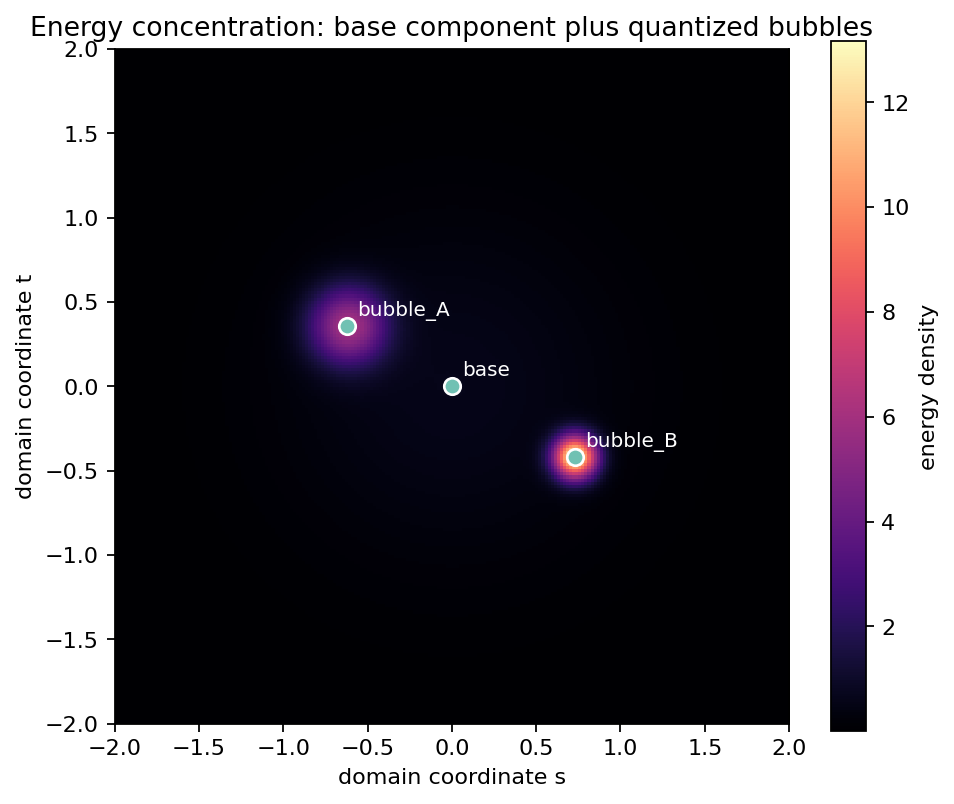

In [3]:
n = 220
x = np.linspace(-2, 2, n)
y = np.linspace(-2, 2, n)
X, Y = np.meshgrid(x, y)
dx = float(x[1] - x[0])
dA = dx * dx
components = [
    {"name": "base", "center": (0.0, 0.0), "sigma": 0.72, "energy": 2.00},
    {"name": "bubble_A", "center": (-0.62, 0.36), "sigma": 0.16, "energy": 0.92},
    {"name": "bubble_B", "center": (0.73, -0.42), "sigma": 0.09, "energy": 0.66},
]
density = np.zeros_like(X)
component_integrals = []
for comp in components:
    cx, cy = comp["center"]
    raw = np.exp(-((X-cx)**2 + (Y-cy)**2)/(2*comp["sigma"]**2))
    scaled = raw * (comp["energy"] / (raw.sum() * dA))
    density += scaled
    component_integrals.append(float(scaled.sum() * dA))
fig, ax = plt.subplots(figsize=(6.8, 5.6))
im = ax.imshow(density, extent=[x.min(), x.max(), y.min(), y.max()], origin="lower", cmap="magma")
for comp in components:
    cx, cy = comp["center"]
    ax.scatter([cx], [cy], s=55, edgecolor="white", facecolor="#70c1b3", linewidth=1.2)
    ax.text(cx + 0.06, cy + 0.06, comp["name"], color="white", fontsize=9)
ax.set_title("Energy concentration: base component plus quantized bubbles")
ax.set_xlabel("domain coordinate s")
ax.set_ylabel("domain coordinate t")
fig.colorbar(im, ax=ax, label="energy density")
fig_path = save_matplotlib(fig, UNIT, "figures", "energy-concentration-bubbles.png")
plt.close(fig)
threshold = 0.5
energy_checks = {
    "component_integrals": dict(zip([c["name"] for c in components], component_integrals)),
    "total_discrete_energy": float(density.sum() * dA),
    "assigned_total_energy": float(sum(c["energy"] for c in components)),
    "minimum_bubble_energy_threshold": threshold,
    "bubble_energies_clear_threshold": bool(all(c["energy"] >= threshold for c in components if c["name"].startswith("bubble"))),
    "energy_conservation_error": float(abs(density.sum() * dA - sum(c["energy"] for c in components))),
    "passed": True,
}
energy_checks["passed"] = energy_checks["energy_conservation_error"] < 1e-10 and energy_checks["bubble_energies_clear_threshold"]
save_json(energy_checks, UNIT, "checks", "energy-quantization-checks.json")
display_artifact(fig_path, width=720)


## 2. Mean-Value and Isoperimetric Estimates

The proof needs estimates that prevent small-energy regions from hiding large derivatives. A mean-value inequality converts local energy on a disk into a pointwise derivative bound. An isoperimetric inequality controls the area filled by a short loop. The ledger below uses simple model rows: each derivative peak stays below its mean-value bound, and each circular loop has the Euclidean ratio `L^2/(4 pi A)=1`. These rows are the computational stand-ins for the analytic estimates used later in removal of singularities.


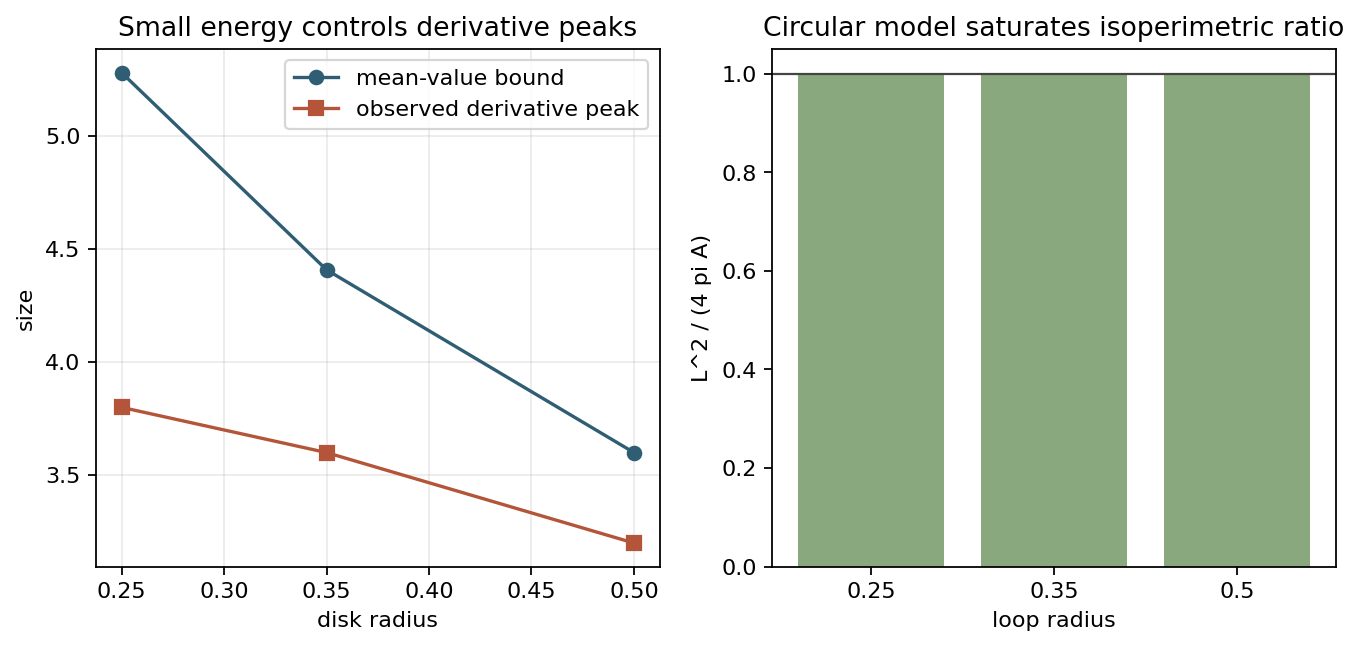

In [4]:
estimate_rows = []
for radius, local_energy, derivative_peak in [(0.25, 0.11, 3.8), (0.35, 0.18, 3.6), (0.50, 0.30, 3.2)]:
    mean_bound = 3.0 * local_energy / (radius**2)
    loop_length = 2 * math.pi * radius
    area = math.pi * radius**2
    iso_ratio = loop_length**2 / (4 * math.pi * area)
    estimate_rows.append({
        "radius": radius,
        "local_energy": local_energy,
        "derivative_peak": derivative_peak,
        "mean_value_bound": mean_bound,
        "mean_value_passes": derivative_peak <= mean_bound,
        "loop_length": loop_length,
        "filled_area": area,
        "isoperimetric_ratio": iso_ratio,
        "isoperimetric_passes": abs(iso_ratio - 1.0) < 1e-12,
    })
estimates = pd.DataFrame(estimate_rows)
estimates.to_csv(TABLE_DIR / "compactness-estimate-ledger.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))
axes[0].plot(estimates["radius"], estimates["mean_value_bound"], marker="o", label="mean-value bound", color="#2f5d73")
axes[0].plot(estimates["radius"], estimates["derivative_peak"], marker="s", label="observed derivative peak", color="#b45539")
axes[0].set_xlabel("disk radius")
axes[0].set_ylabel("size")
axes[0].set_title("Small energy controls derivative peaks")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].bar([str(r) for r in estimates["radius"]], estimates["isoperimetric_ratio"], color="#8aa87d")
axes[1].axhline(1.0, color="#444", lw=1.0)
axes[1].set_xlabel("loop radius")
axes[1].set_ylabel("L^2 / (4 pi A)")
axes[1].set_title("Circular model saturates isoperimetric ratio")
fig_path = save_matplotlib(fig, UNIT, "figures", "mean-value-isoperimetric-estimates.png")
plt.close(fig)
estimate_checks = {
    "rows": int(len(estimates)),
    "all_mean_value_rows_pass": bool(estimates["mean_value_passes"].all()),
    "all_isoperimetric_rows_pass": bool(estimates["isoperimetric_passes"].all()),
    "max_isoperimetric_error": float(np.max(np.abs(estimates["isoperimetric_ratio"] - 1.0))),
    "passed": bool(estimates["mean_value_passes"].all() and estimates["isoperimetric_passes"].all()),
}
save_json(estimate_checks, UNIT, "checks", "mean-value-isoperimetric-checks.json")
display_artifact(fig_path, width=980)


## 3. Rescaling and the Bubble Tree

Convergence modulo bubbling is a two-scale statement. Away from concentration points the maps converge on the base domain; near a concentration point, shrinking coordinates reveal a new sphere. The rescaling chart keeps a fixed bubble energy visible as the domain scale shrinks. The tree figure then records the output of Section 4.7: extracted bubbles are not a disconnected pile, but a connected tree attached to the base component through nodes.


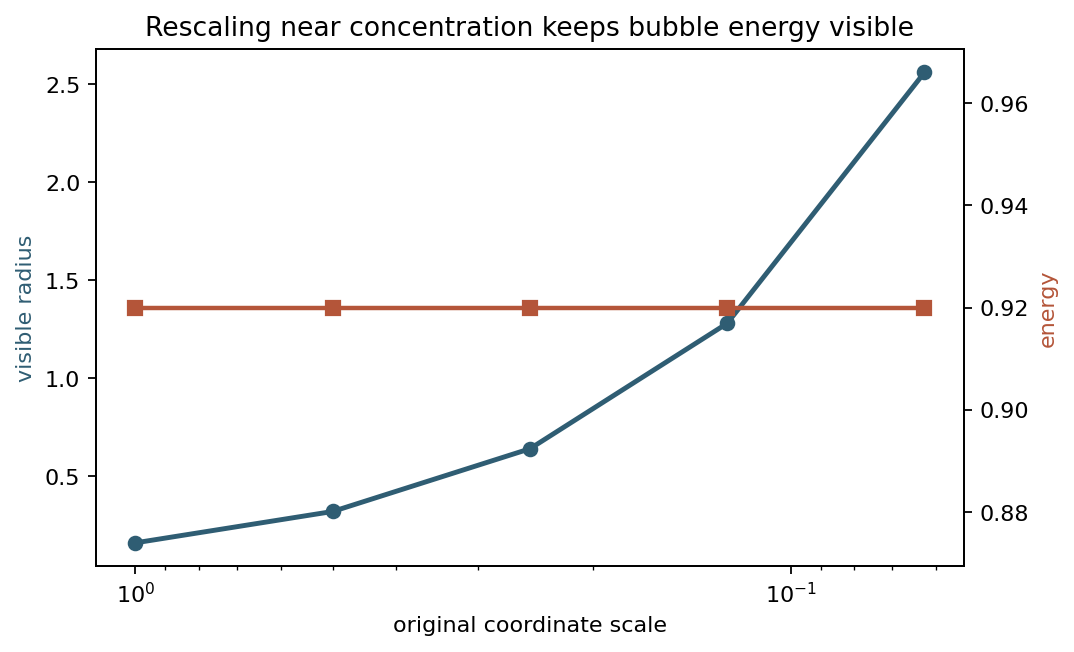

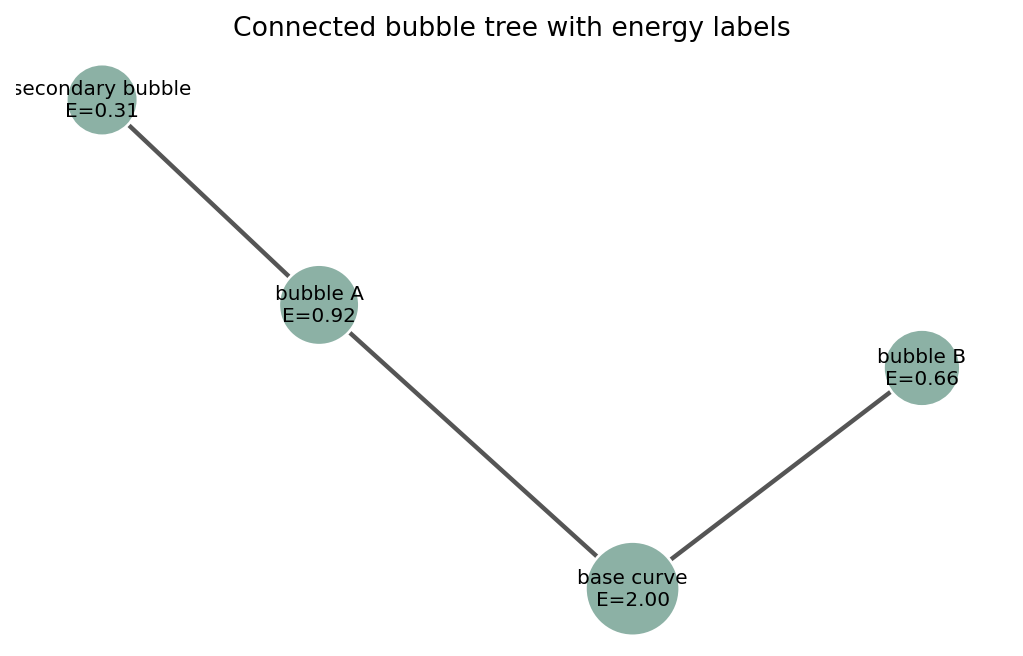

In [5]:
scales = np.array([1.0, 0.5, 0.25, 0.125, 0.0625])
visible_radius = 0.16 / scales
rescaled_energy = np.full_like(scales, 0.92, dtype=float)
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(scales, visible_radius, marker="o", lw=2.2, color="#2f5d73", label="bubble radius in rescaled chart")
ax2 = ax.twinx()
ax2.plot(scales, rescaled_energy, marker="s", lw=2.0, color="#b45539", label="rescaled bubble energy")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("original coordinate scale")
ax.set_ylabel("visible radius", color="#2f5d73")
ax2.set_ylabel("energy", color="#b45539")
ax.set_title("Rescaling near concentration keeps bubble energy visible")
fig_path = save_matplotlib(fig, UNIT, "figures", "bubble-rescaling-profile.png")
plt.close(fig)

G = nx.Graph()
G.add_edges_from([("base curve", "bubble A"), ("base curve", "bubble B"), ("bubble A", "secondary bubble")])
energies = {"base curve": 2.00, "bubble A": 0.92, "bubble B": 0.66, "secondary bubble": 0.31}
pos = {"base curve": (0, 0), "bubble A": (-1.3, 0.9), "bubble B": (1.2, 0.7), "secondary bubble": (-2.2, 1.55)}
node_sizes = [900 + 450*energies[node] for node in G.nodes]
fig, ax = plt.subplots(figsize=(8.0, 4.8))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#8cb1a5", edgecolors="white", linewidths=1.2, ax=ax)
nx.draw_networkx_edges(G, pos, width=2.0, edge_color="#555", ax=ax)
nx.draw_networkx_labels(G, pos, labels={n: f"{n}\nE={energies[n]:.2f}" for n in G.nodes}, font_size=9, ax=ax)
ax.set_title("Connected bubble tree with energy labels")
ax.axis("off")
tree_path = save_matplotlib(fig, UNIT, "figures", "compactness-bubble-tree.png")
plt.close(fig)
rescaling_checks = {
    "rescaled_energy_variation": float(np.max(rescaled_energy) - np.min(rescaled_energy)),
    "visible_radius_increases_under_zoom": bool(np.all(np.diff(visible_radius) > 0)),
    "tree_connected": bool(nx.is_connected(G)),
    "tree_acyclic": bool(nx.is_tree(G)),
    "total_tree_energy": float(sum(energies.values())),
    "passed": bool(np.all(np.diff(visible_radius) > 0) and nx.is_tree(G)),
}
save_json(rescaling_checks, UNIT, "checks", "rescaling-bubble-tree-checks.json")
display_artifact(fig_path, width=700)
display_artifact(tree_path, width=800)


## 4. Proof Dependencies from Estimates to Compactness

The analytic proof has a recognizable flow. Energy bounds identify possible concentration points. Mean-value estimates control derivatives away from them. Isoperimetric control and removal of singularities fill punctures. Rescaling extracts bubbles. Energy quantization prevents infinitely many large bubbles. Finally, the connectedness argument links all components into a tree. The graph below is a proof checklist, not decoration: each edge records an input needed before the next step is justified.


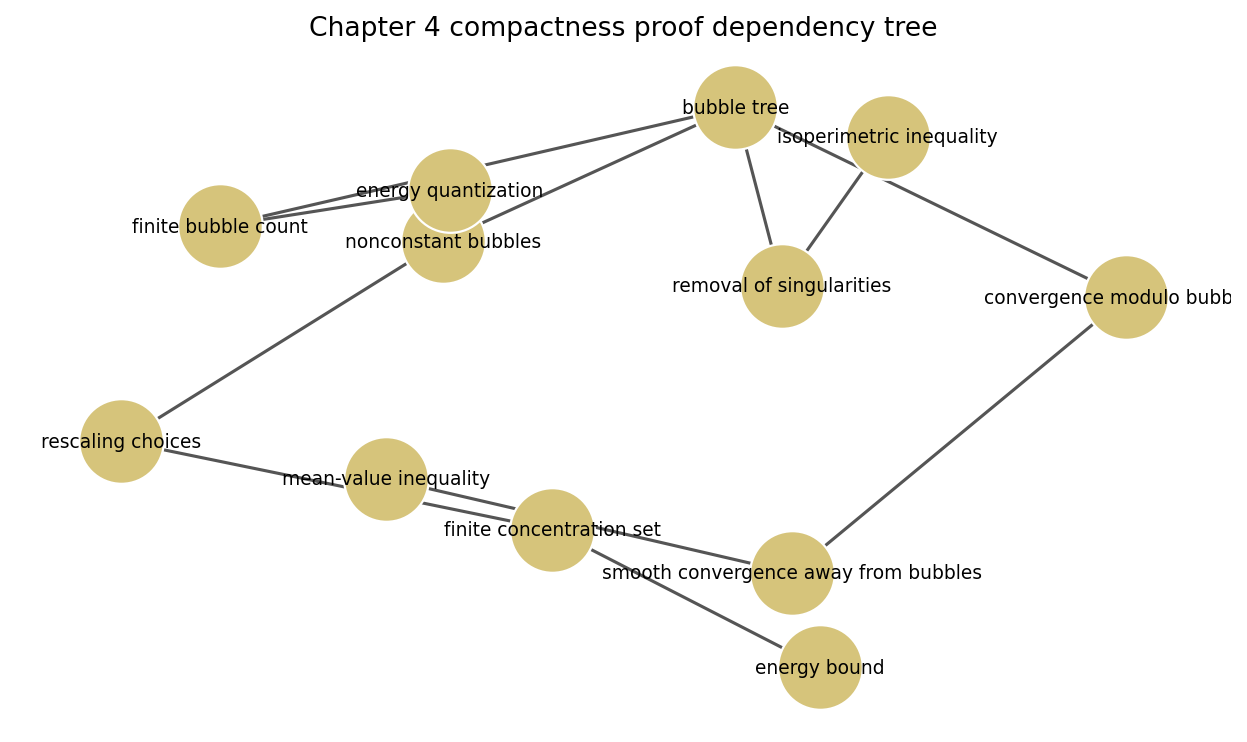

In [6]:
P = nx.DiGraph()
P.add_edges_from([
    ("energy bound", "finite concentration set"),
    ("mean-value inequality", "smooth convergence away from bubbles"),
    ("isoperimetric inequality", "removal of singularities"),
    ("finite concentration set", "rescaling choices"),
    ("rescaling choices", "nonconstant bubbles"),
    ("energy quantization", "finite bubble count"),
    ("nonconstant bubbles", "bubble tree"),
    ("finite bubble count", "bubble tree"),
    ("removal of singularities", "bubble tree"),
    ("smooth convergence away from bubbles", "convergence modulo bubbling"),
    ("bubble tree", "convergence modulo bubbling"),
])
pos = nx.spring_layout(P, seed=404, k=1.05)
fig, ax = plt.subplots(figsize=(9.8, 5.5))
nx.draw_networkx_nodes(P, pos, node_color="#d6c47b", node_size=1450, edgecolors="white", linewidths=1.0, ax=ax)
nx.draw_networkx_edges(P, pos, arrowstyle="-|>", arrowsize=14, width=1.4, edge_color="#555", ax=ax)
nx.draw_networkx_labels(P, pos, font_size=8.4, ax=ax)
ax.set_title("Chapter 4 compactness proof dependency tree")
ax.axis("off")
fig_path = save_matplotlib(fig, UNIT, "figures", "compactness-proof-tree.png")
plt.close(fig)
proof_checks = {
    "nodes": int(P.number_of_nodes()),
    "edges": int(P.number_of_edges()),
    "has_removal_path": bool(nx.has_path(P, "isoperimetric inequality", "convergence modulo bubbling")),
    "has_rescaling_path": bool(nx.has_path(P, "energy bound", "nonconstant bubbles")),
    "passed": bool(nx.has_path(P, "energy bound", "convergence modulo bubbling") and nx.has_path(P, "isoperimetric inequality", "convergence modulo bubbling")),
}
save_json(proof_checks, UNIT, "checks", "compactness-proof-tree.json")
display_artifact(fig_path, width=940)


## Applied Lab

The lab varies bubble width and threshold. Narrower peaks have higher density, but compactness only treats them as bubbles if enough energy is trapped. This separates a visual spike from a genuine bubble: a sharp peak below threshold is controlled by the estimates, while a peak above threshold must be recorded as a new component after rescaling. The table is deliberately small so a reader can inspect every case.


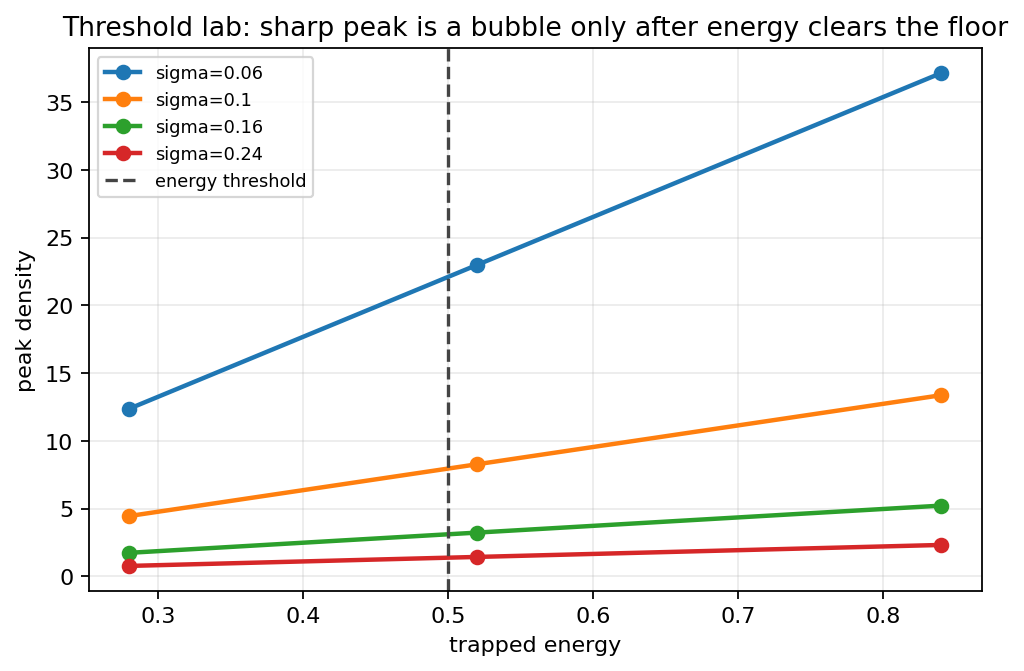

In [7]:
lab_rows = []
for sigma in [0.06, 0.10, 0.16, 0.24]:
    for bubble_energy in [0.28, 0.52, 0.84]:
        peak_density = bubble_energy / (2 * math.pi * sigma**2)
        detected = bubble_energy >= threshold
        lab_rows.append({"sigma": sigma, "bubble_energy": bubble_energy, "peak_density": peak_density, "threshold": threshold, "detected_as_bubble": detected})
lab = pd.DataFrame(lab_rows)
lab.to_csv(TABLE_DIR / "bubble-threshold-lab.csv", index=False)
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for sigma, group in lab.groupby("sigma"):
    ax.plot(group["bubble_energy"], group["peak_density"], marker="o", lw=2, label=f"sigma={sigma}")
ax.axvline(threshold, color="#444", linestyle="--", label="energy threshold")
ax.set_xlabel("trapped energy")
ax.set_ylabel("peak density")
ax.set_title("Threshold lab: sharp peak is a bubble only after energy clears the floor")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "bubble-threshold-lab.png")
plt.close(fig)
lab_checks = {
    "rows": int(len(lab)),
    "has_detected_bubbles": bool(lab["detected_as_bubble"].any()),
    "has_subthreshold_peaks": bool((~lab["detected_as_bubble"]).any()),
    "detection_matches_threshold": bool((lab["detected_as_bubble"] == (lab["bubble_energy"] >= lab["threshold"])).all()),
    "passed": True,
}
lab_checks["passed"] = lab_checks["has_detected_bubbles"] and lab_checks["has_subthreshold_peaks"] and lab_checks["detection_matches_threshold"]
save_json(lab_checks, UNIT, "checks", "bubble-threshold-lab-checks.json")
display_artifact(fig_path, width=720)


## Takeaways

- Compactness is an energy accounting theorem: bounded energy cannot disappear, but it may move into bubbles after rescaling.
- Mean-value and isoperimetric estimates are the local controls that turn small energy into smooth convergence and removable punctures.
- Energy quantization gives finiteness. Without a positive threshold, a bounded-energy sequence could shed infinitely many invisible pieces.
- The limiting object is connected as a bubble tree, which is the analytic ancestor of the stable maps used in the next chapter.
- When reading compactness arguments later, track four things: where energy concentrates, what scale reveals a bubble, how much energy the bubble carries, and how the components attach.


## Final Sanity Checks

The final cell verifies the notebook contract: source coverage, library routing, storyboard, energy heatmap, estimate ledger, rescaling chart, bubble tree, proof graph, threshold lab, and all JSON checks must exist. It then reloads the checks to confirm energy conservation, estimate validity, connected bubble-tree structure, proof paths, and threshold detection.


In [8]:
expected_artifacts = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "library-routing.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "energy-quantization-checks.json",
    CHECK_DIR / "mean-value-isoperimetric-checks.json",
    CHECK_DIR / "rescaling-bubble-tree-checks.json",
    CHECK_DIR / "compactness-proof-tree.json",
    CHECK_DIR / "bubble-threshold-lab-checks.json",
    FIG_DIR / "energy-concentration-bubbles.png",
    FIG_DIR / "mean-value-isoperimetric-estimates.png",
    FIG_DIR / "bubble-rescaling-profile.png",
    FIG_DIR / "compactness-bubble-tree.png",
    FIG_DIR / "compactness-proof-tree.png",
    FIG_DIR / "bubble-threshold-lab.png",
    TABLE_DIR / "compactness-estimate-ledger.csv",
    TABLE_DIR / "bubble-threshold-lab.csv",
]
for artifact in expected_artifacts:
    assert_artifact(artifact)
assert_artifact(CHECK_DIR / "source-coverage.json")
assert_artifact(CHECK_DIR / "visual-storyboard.json")
assert_artifact(FIG_DIR / "energy-concentration-bubbles.png")
assert_artifact(FIG_DIR / "compactness-bubble-tree.png")

check_names = ["energy-quantization-checks.json", "mean-value-isoperimetric-checks.json", "rescaling-bubble-tree-checks.json", "compactness-proof-tree.json", "bubble-threshold-lab-checks.json"]
checks = [json.loads((CHECK_DIR / name).read_text(encoding="utf-8")) for name in check_names]
final_sanity = {
    "artifact_count": len(expected_artifacts),
    "all_json_checks_passed": all(item.get("passed", False) for item in checks),
    "energy_conserved": checks[0]["energy_conservation_error"] < 1e-10,
    "estimate_rows_pass": checks[1]["all_mean_value_rows_pass"] and checks[1]["all_isoperimetric_rows_pass"],
    "bubble_tree_is_tree": checks[2]["tree_connected"] and checks[2]["tree_acyclic"],
    "threshold_lab_has_both_outcomes": checks[4]["has_detected_bubbles"] and checks[4]["has_subthreshold_peaks"],
    "passed": True,
}
final_sanity["passed"] = all(value for key, value in final_sanity.items() if key != "artifact_count")
save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(CHECK_DIR / "final-sanity.json")
final_sanity


{'artifact_count': 16,
 'all_json_checks_passed': True,
 'energy_conserved': True,
 'estimate_rows_pass': True,
 'bubble_tree_is_tree': True,
 'threshold_lab_has_both_outcomes': True,
 'passed': True}